<a href="https://colab.research.google.com/github/Selvapriya05/Selvapriya-Codeboosters-2026/blob/main/Day_2/Day_2_miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully!
   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedab

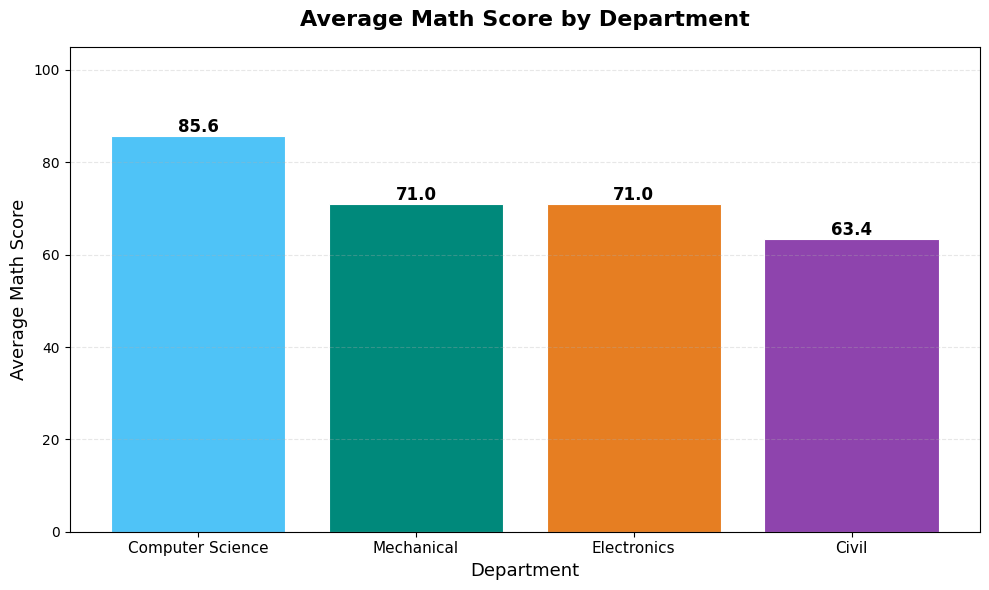

In [ ]:
# Import libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv('student_performance.csv')

print("Dataset Loaded Successfully!")
print(df.head())

# Create SQLite database connection
conn = sqlite3.connect('college.db')

# Store dataframe into SQL table
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

print("Database created successfully!")

# SQL query for chart data
chart1_sql = """
SELECT department,
       ROUND(AVG(math_score), 2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

# Read SQL result into dataframe
chart1_data = pd.read_sql_query(chart1_sql, conn)

print(chart1_data)

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']

bars = ax.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

# Add values on top of bars
for bar in bars:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color='black'
    )

# Chart formatting
ax.set_title(
    'Average Math Score by Department',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Math Score', fontsize=13)

ax.set_ylim(0, 105)

ax.tick_params(axis='x', labelsize=11)

ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()

# Show chart
plt.show()

# Close database
conn.close()

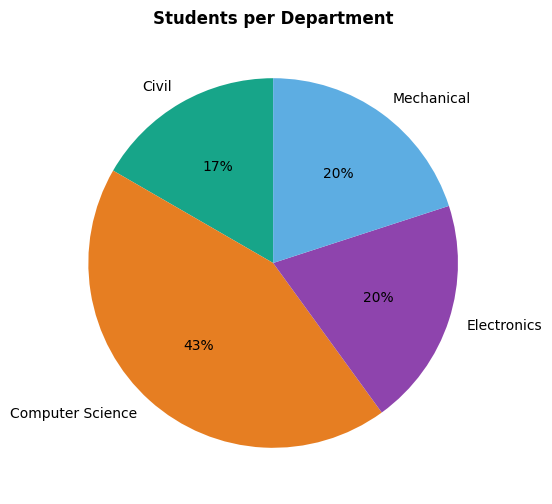

In [ ]:
# Import libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('student_performance.csv')

# Create database
conn = sqlite3.connect('college.db')

# Store dataframe into SQL table
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

# SQL query
pie_sql = """
SELECT department,
       COUNT(*) AS total_students
FROM students
GROUP BY department
"""

# Read query result
pie_data = pd.read_sql_query(pie_sql, conn)

# Create pie chart
plt.figure(figsize=(6,6))

colors = ['#17A589', '#E67E22', '#8E44AD', '#5DADE2']

plt.pie(
    pie_data['total_students'],
    labels=pie_data['department'],
    autopct='%1.0f%%',
    startangle=90,
    colors=colors
)

# Title
plt.title('Students per Department', fontsize=12, fontweight='bold')

# Show chart
plt.show()

# Close connection
conn.close()

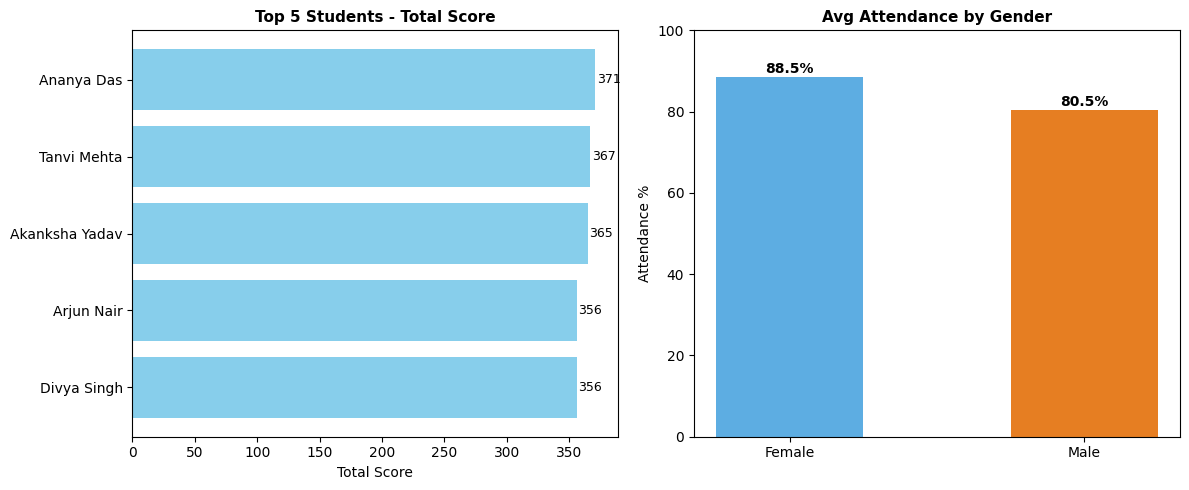

In [ ]:
# Import libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('student_performance.csv')

# Create SQLite database
conn = sqlite3.connect('college.db')

# Store dataframe into SQL table
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

# -------------------------------
# Chart 1 : Top 5 Students
# -------------------------------

top_students_sql = """
SELECT
    name,
    (math_score + science_score + english_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 5;
"""

top_students = pd.read_sql_query(top_students_sql, conn)

# -------------------------------
# Chart 2 : Avg Attendance by Gender
# -------------------------------

attendance_sql = """
SELECT
    gender,
    ROUND(AVG(attendance_percentage),1) AS avg_attendance
FROM students
GROUP BY gender;
"""

attendance_data = pd.read_sql_query(attendance_sql, conn)

# -------------------------------
# Create Subplots
# -------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# =====================================
# Left Chart : Horizontal Bar Chart
# =====================================

axes[0].barh(
    top_students['name'],
    top_students['total_score'],
    color='skyblue'
)

axes[0].invert_yaxis()

axes[0].set_title(
    'Top 5 Students - Total Score',
    fontsize=11,
    fontweight='bold'
)

axes[0].set_xlabel('Total Score')

# Add score labels
for i, value in enumerate(top_students['total_score']):
    axes[0].text(
        value + 1,
        i,
        str(value),
        va='center',
        fontsize=9
    )

# =====================================
# Right Chart : Bar Chart
# =====================================

bars = axes[1].bar(
    attendance_data['gender'],
    attendance_data['avg_attendance'],
    color=['#5DADE2', '#E67E22'],
    width=0.5
)

axes[1].set_title(
    'Avg Attendance by Gender',
    fontsize=11,
    fontweight='bold'
)

axes[1].set_ylabel('Attendance %')

axes[1].set_ylim(0, 100)

# Add attendance labels
for bar in bars:

    height = bar.get_height()

    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Layout
plt.tight_layout()

# Show output
plt.show()

# Close database
conn.close()